In [6]:
!pip install arch

In [29]:
# Importing libraries
import pandas as pd
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from arch import arch_model
from tqdm import tqdm
import yfinance as yf

# Loading and Filtering Data

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
# Loading the data
crude_data= pd.read_csv(r"/content/drive/MyDrive/Sem 2/Crude_Oil_data.csv", index_col= None)
crude_data.head()

,Date,Price
0,"Jan 02, 1986",25.56
1,"Jan 03, 1986",26.00
2,"Jan 06, 1986",26.53
3,"Jan 07, 1986",25.85
4,"Jan 08, 1986",25.87


In [10]:
# Filtering the data
crude_data["Date"] = pd.to_datetime(crude_data["Date"])
crude_data = crude_data[crude_data["Date"] >= pd.Timestamp("2010-01-01")].reset_index(drop=True)
crude_data = crude_data[crude_data["Price"] > 0].copy()
crude_data= crude_data.dropna()
crude_data.head()
crude_data.tail()

,Date,Price
4029,2026-01-27,62.04
4030,2026-01-28,62.75
4031,2026-01-29,64.77
4032,2026-01-30,64.50
4033,2026-02-02,61.60


In [11]:
# Calculating log returns
crude_data= crude_data.dropna()
crude_data["Log Returns"]= np.log(crude_data["Price"] / crude_data["Price"].shift(1))
crude_data= crude_data.dropna()
crude_data.head()

,Date,Price,Log Returns
1,2010-01-05,81.74,0.002695
2,2010-01-06,83.12,0.016742
3,2010-01-07,82.60,-0.006276
4,2010-01-08,82.74,0.001693
5,2010-01-11,82.54,-0.002420


# Exploratory Data Analysis

In [12]:
crude_data.size

12096

In [13]:
crude_data.isna().sum()

,0
Date,0
Price,0
Log Returns,0


In [14]:
crude_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4032 entries, 1 to 4033
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         4032 non-null   datetime64[ns]
 1   Price        4032 non-null   float64       
 2   Log Returns  4032 non-null   float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 126.0 KB


In [15]:
crude_data.describe()

,Date,Price,Log Returns
count,4032,4032.000000,4032.000000
mean,2018-01-09 16:06:25.714285824,71.625159,-0.000069
min,2010-01-05 00:00:00,8.910000,-0.720273
25%,2014-01-02 18:00:00,54.407500,-0.011729
50%,2018-01-04 12:00:00,71.625000,0.000800
75%,2022-01-15 00:00:00,88.205000,0.012286
max,2026-02-02 00:00:00,123.640000,0.425832
std,NaN,20.802058,0.029376


In [16]:
# Visualising the price over time
fig1= px.line(data_frame= crude_data, x= "Date", y= "Price", title= "Closing Price Data for Crude Oil")
fig1.show()

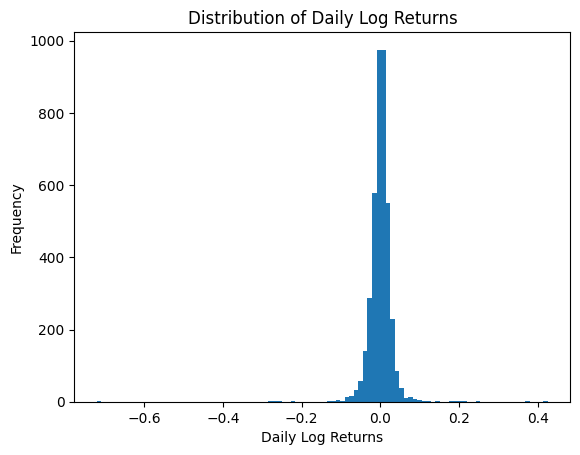

In [17]:
# Visualising the distribution of daily log returns
plt.figure()
plt.hist(crude_data["Log Returns"].dropna(), bins=100)
plt.xlabel("Daily Log Returns")
plt.ylabel("Frequency")
plt.title("Distribution of Daily Log Returns")
plt.show()

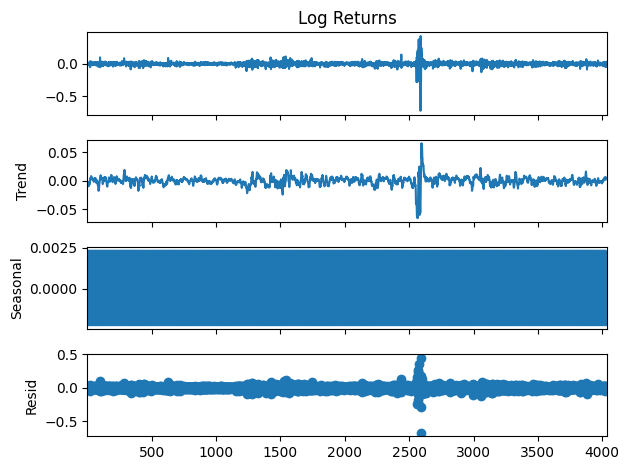

In [18]:
decompose = seasonal_decompose(crude_data["Log Returns"], period=12).plot()
#period: how many times calculated in a year (12=monthly, 4=quarterly, 1=annual)

Text(0, 0.5, 'Returns')

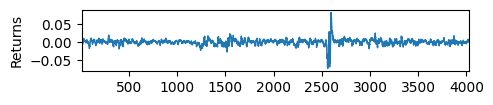

In [19]:
plt.figure(figsize=(5, 0.8))
crude_data["Log Returns"].rolling(window=12, center=True).mean().plot(lw=1)
plt.margins(x=0)
plt.ylabel('Returns')

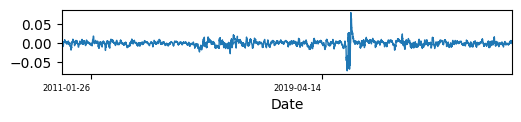

In [20]:
# 1. Ensure Date is the index (crucial for x-axis labeling)
crude_data['Date'] = pd.to_datetime(crude_data['Date'])
crude_data.set_index('Date', inplace=True)

plt.figure(figsize=(5, 0.8))

# 2. Plot the rolling mean
ax = crude_data["Log Returns"].rolling(window=12, center=True).mean().plot(lw=1)

# 3. Format the x-axis to show only the Year
plt.margins(x=0)
plt.xticks(rotation=0)
ax.xaxis.set_major_locator(ticker.MaxNLocator(2)) # Limit to 2 ticks as requested
plt.tick_params(axis='x', labelsize=6)

# 4. Remove all whitespace
plt.tight_layout(pad=0)
plt.subplots_adjust(left=0.1, right=1, top=1, bottom=0.2) # Adjusted for label visibility

plt.show()

# Assumption Testing

In [21]:
# ADF Test

def adf_test(timeseries):
    print("Results of Dickey-Fuller Test:")
    dftest = adfuller(timeseries, autolag="AIC")
    dfoutput = pd.Series(
        dftest[0:4],
        index=[
            "Test Statistic",
            "p-value",
            "#Lags Used",
            "Number of Observations Used",
        ],
    )
    for key, value in dftest[4].items():
        dfoutput["Critical Value (%s)" % key] = value
    print(dfoutput)

In [22]:
series = crude_data["Log Returns"]
output = adf_test(series)

Results of Dickey-Fuller Test:
Test Statistic                -1.044725e+01
p-value                        1.469183e-18
#Lags Used                     2.800000e+01
Number of Observations Used    4.003000e+03
Critical Value (1%)           -3.431985e+00
Critical Value (5%)           -2.862262e+00
Critical Value (10%)          -2.567154e+00
dtype: float64


In [23]:
# Ljung-Box Test

squared_returns = series**2 # using squared_return to check variance dependence i.e. if a big shock today leads to a big shock tomorrow
lb_results = acorr_ljungbox(squared_returns, lags=[10, 15, 20, 100], return_df=True) # testing up to 10 lags to see short-to-medium term persistence
lb_results


,lb_stat,lb_pvalue
10,801.649670,9.118804e-166
15,1099.795174,5.337844e-225
20,1300.530165,2.278017e-263
100,1569.599404,1.790020e-262


# GJR-GARCH Implementation

In [24]:
scaled_returns = 100 * crude_data['Log Returns']

In [25]:
# 1. Define the combinations (p, o, q)
# The order is (p=GARCH lag, o=GJR/Asymmetry lag, q=ARCH lag)
combinations = [
    (1, 1, 1), (2, 1, 1), (1, 2, 1), (1, 1, 2),
    (2, 2, 1), (2, 1, 2), (1, 2, 2), (2, 2, 2)
]

# 2. Store results in a list
results_list = []

# 3. Loop through combinations
for p, o, q in combinations:
    try:
        # Fit the model
        model = arch_model(scaled_returns, vol='GARCH', p=p, o=o, q=q, dist='t')
        res = model.fit(disp='off')

        # Save the scores
        results_list.append({
            'Model': f'({p},{o},{q})',
            'AIC': res.aic,
            'BIC': res.bic,
        })
    except Exception as e:
        print(f"Model ({p},{o},{q}) failed to converge: {e}")

# 4. Display as a DataFrame
comparison_df = pd.DataFrame(results_list)
comparison_df = comparison_df.sort_values(by='AIC') # Sort by best AIC
print(comparison_df)

     Model           AIC           BIC
0  (1,1,1)  17108.725339  17146.537446
3  (1,1,2)  17110.604170  17154.718295
1  (2,1,1)  17110.725339  17154.839464
2  (1,2,1)  17110.725340  17154.839464
7  (2,2,2)  17112.217648  17168.935808
5  (2,1,2)  17112.582804  17162.998946
6  (1,2,2)  17112.604170  17163.020313
4  (2,2,1)  17112.710174  17163.126317


In [26]:
# Fit the GJR-GARCH(1,1,1) model
model_gjr_111 = arch_model(scaled_returns, vol='GARCH', p=1, o=1, q=1, dist='t')
results_gjr_111 = model_gjr_111.fit(disp='off')

# Print the summary
print(results_gjr_111.summary())

                      Constant Mean - GJR-GARCH Model Results                       
Dep. Variable:                  Log Returns   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                        GJR-GARCH   Log-Likelihood:               -8548.36
Distribution:      Standardized Student's t   AIC:                           17108.7
Method:                  Maximum Likelihood   BIC:                           17146.5
                                              No. Observations:                 4032
Date:                      Thu, Apr 23 2026   Df Residuals:                     4031
Time:                              15:29:25   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu     

# Validating the Model using The Ljung Box Test

In [27]:
std_resid_sq = results_gjr_111.std_resid ** 2
lb_test = acorr_ljungbox(std_resid_sq, lags=[5, 10, 15, 20,100], return_df=True)
print("Ljung-Box Test for Squared Residuals:")
print(lb_test)

Ljung-Box Test for Squared Residuals:
        lb_stat  lb_pvalue
5      5.800056   0.326163
10     8.068419   0.622154
15    12.602658   0.632958
20    15.508579   0.746605
100  121.069657   0.074533


# Generating a Conditional Volatility Forecast

In [30]:
# Computing the realized volatilities for the forecasted 10 day period

lookback = 252*2

realized_data = yf.download(tickers = 'CL=F', start = "2023-12-20", end = "2026-01-17")

realized_data = realized_data.dropna()

realized_10day_logret = np.log(realized_data['Close'] / realized_data['Close'].shift(1))
realized_10day_logret = 100 * realized_10day_logret.dropna()

realized_10day_vol = realized_10day_logret.rolling(window = lookback).std()
realized_10day_vol = realized_10day_vol.tail(10)

realized_10day_vol = realized_10day_vol.squeeze().astype(float).reset_index(drop=True)

print(realized_10day_vol)
print(type(realized_10day_vol))

/tmp/ipykernel_2654/3611132045.py:5: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed

0    1.898453
1    1.900354
2    1.899678
3    1.895851
4    1.896486
5    1.896005
6    1.899559
7    1.900185
8    1.911325
9    1.911400
Name: CL=F, dtype: float64
<class 'pandas.core.series.Series'>


--- WTI VOLATILITY FORECAST TABLE ---
  Step  Projected Volatility (%)  Vs. Long-Run Avg (%)
 Day 1                    2.4814                0.2428
 Day 2                    2.4759                0.2373
 Day 3                    2.4705                0.2319
 Day 4                    2.4651                0.2265
 Day 5                    2.4600                0.2214
 Day 6                    2.4549                0.2163
 Day 7                    2.4499                0.2113
 Day 8                    2.4451                0.2065
 Day 9                    2.4403                0.2017
Day 10                    2.4357                0.1971

Model Unconditional Volatility: 2.2386%


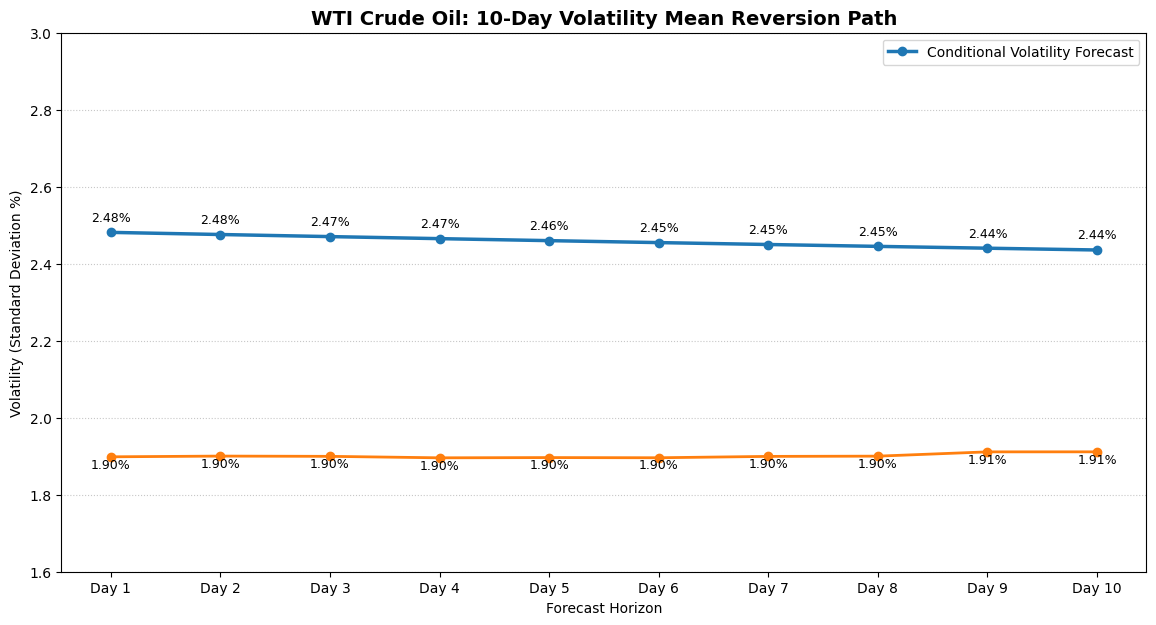

In [35]:
# 1. Extract parameters for the Long-Run Volatility calculation
omega = results_gjr_111.params['omega']
alpha = results_gjr_111.params['alpha[1]']
gamma = results_gjr_111.params['gamma[1]']
beta = results_gjr_111.params['beta[1]']

# Calculation for GJR-GARCH Unconditional Volatility
# (Note: 0.5 * gamma accounts for the probability of negative shocks)
unconditional_var = omega / (1 - alpha - beta - 0.5 * gamma)
unconditional_vol = np.sqrt(unconditional_var)

# 2. Generate the 10-day Forecast
horizon = 10
forecasts = results_gjr_111.forecast(horizon=horizon, reindex=False)
pred_vol = np.sqrt(forecasts.variance.iloc[-1])

# 3. Create the Forecast Table
forecast_steps = [f'Day {i+1}' for i in range(horizon)]
forecast_table = pd.DataFrame({
    'Step': forecast_steps,
    'Projected Volatility (%)': pred_vol.values.round(4),
    'Vs. Long-Run Avg (%)': (pred_vol.values - unconditional_vol).round(4)
})

# 4. Visualization
plt.figure(figsize=(14, 7))

# Plot the 10-day trend
plt.plot(forecast_steps, pred_vol, marker='o',
         linewidth=2.5, label='Conditional Volatility Forecast')
plt.plot(forecast_steps, realized_10day_vol, marker='o', color='#ff7f0e', lw=2)

for i, v in enumerate(pred_vol):
    plt.annotate(
        f"{v:.2f}%",
        (i, v),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=9
    )

for i, v in enumerate(realized_10day_vol):
    plt.annotate(
        f"{v:.2f}%",
        (i, v),
        textcoords="offset points",
        xytext=(0, -8),
        ha="center",
        fontsize=9
    )

# Formatting the Chart
plt.ylim(1.60, 3.0)
plt.title("WTI Crude Oil: 10-Day Volatility Mean Reversion Path", fontsize=14, fontweight='bold')
plt.ylabel("Volatility (Standard Deviation %)")
plt.xlabel("Forecast Horizon")
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.legend()

# Display results
print("--- WTI VOLATILITY FORECAST TABLE ---")
print(forecast_table.to_string(index=False))
print(f"\nModel Unconditional Volatility: {unconditional_vol:.4f}%")
plt.show()

In [ ]:
# ============================
# Rolling 10-day forecast performance
# ============================

rolling_window = 252*2
forecast_horizon = 10

best_key = (1,1,1)
p_best, o_best, q_best = best_key

forecasted_10d = []
realized_10d = []
forecast_dates_10d = []

for i in tqdm(range(rolling_window, len(scaled_returns) - forecast_horizon + 1), desc="Rolling 10D"):
    train_data = scaled_returns.iloc[i - rolling_window:i].dropna()

    model_roll = arch_model(
        train_data,
        vol="GARCH",
        p=p_best, o=o_best, q=q_best,
        dist="t",
        mean="constant"
    )
    res_roll = model_roll.fit(disp="off")

    fc = res_roll.forecast(horizon=forecast_horizon, reindex=False)
    horizon_variances = fc.variance.values[-1]

    # Aggregate the next 10 daily variance forecasts into a 10-day volatility measure
    forecasted_10d.append(np.sqrt(np.mean(horizon_variances)) * np.sqrt(252))

    future_returns = scaled_returns.iloc[i:i + forecast_horizon]
    realized_10d.append(float(future_returns.std(ddof=1)) * np.sqrt(252))
    forecast_dates_10d.append(scaled_returns.index[i + forecast_horizon - 1])

rolling_10d = pd.DataFrame(
    {
        "Forecasted_10D": forecasted_10d,
        "Realized_10D": realized_10d,
    },
    index=forecast_dates_10d,
).dropna()

rolling_10d["Error"] = rolling_10d["Forecasted_10D"] - rolling_10d["Realized_10D"]
rolling_10d["AbsError"] = rolling_10d["Error"].abs()
rolling_10d["SquaredError"] = rolling_10d["Error"] ** 2

corr_10d = rolling_10d[["Forecasted_10D", "Realized_10D"]].corr().iloc[0, 1]
mae_10d = rolling_10d["AbsError"].mean()
rmse_10d = np.sqrt(rolling_10d["SquaredError"].mean())
bias_10d = rolling_10d["Error"].mean()

print(f"10-day forecast correlation: {corr_10d:.4f}")
print(f"10-day forecast MAE: {mae_10d:.4f}")
print(f"10-day forecast RMSE: {rmse_10d:.4f}")
print(f"10-day forecast bias: {bias_10d:.4f}")

display(rolling_10d.head())

ax = rolling_10d[["Forecasted_10D", "Realized_10D"]].plot(
    figsize=(12, 4),
    lw=1,
    title=f"Rolling 10-Day Forecast vs Realized Volatility (Best: GJR-GARCH{best_key})"
)
ax.set_ylabel("Annualized Volatility (%)")
plt.tight_layout()
plt.show()
